# Corrected IP attribution, campaign-stage detection, and lead-time analysis

This notebook is a clean replacement for the IP/MITRE/lead-time portions of `mitre_comparison.ipynb`. It does **not** modify that notebook.

It addresses the problems found during the forensic review:

1. The saved Day-1 and Day-2 `ip_map` files were not the maps used when the graphs were generated. They contain the same IP sets but a different ID permutation.
2. The graph contents, edge order, labels, and global node identities were internally consistent. Therefore, the trained models and their validation-derived thresholds remain valid; only IP-level decoding and all analyses based on decoded IPs must be recomputed.
3. Results involving decoded addresses such as `172.31.64.4`, `172.31.64.44`, and `172.31.0.2` from the old notebook are invalid.
4. Volume-based inference of C2 and attacker IPs selected shared services and missed the documented campaign endpoints. This notebook uses the documented scenario endpoints instead.
5. Internal traffic on SMB/admin ports is not sufficient evidence of lateral movement. The documented late internal phase is an Nmap scan, which is treated as **Discovery / internal reconnaissance**.
6. Lead time is measured to the onset of that documented late stage. Ground-truth opportunity, detected malicious precursor, source-host alert, and either-endpoint alert are kept separate.

Dataset correction reference: [CSECICIDS2018 corrected documentation](https://intrusion-detection.distrinet-research.be/CNS2022/CSECICIDS2018.html).


## Execution notes

- Run the notebook from top to bottom.
- In Colab, mount Drive and make sure the project code exists at `/content/temporalgnn-nids/code/python`, as in the original notebook.
- In a fresh Colab runtime, install the project dependency first with `%pip install torch_geometric -q`.
- The default analysis-data directory in Colab is `/content/drive/MyDrive/nids-mitre`.
- Locally, set the environment variable `NIDS_ANALYSIS_ROOT` if the datasets/checkpoints are outside the repository.
- The expensive raw-to-graph audits are included for reproducibility but disabled by default because they have already been run. Set `RUN_FULL_RAW_GRAPH_AUDIT = True` to repeat them.
- All caches and CSVs use a new directory. Nothing from the old decoded-IP analysis is reused.


In [ ]:
# ============================================================
# SETUP - Run this cell first
# ============================================================
!git clone -b feat/fair-comparison-experiments https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/nids-mitre/')



Cloning into 'temporalgnn-nids'...
remote: Enumerating objects: 1108, done.
remote: Counting objects: 100% (317/317), done.
remote: Compressing objects: 100% (210/210), done.
remote: Total 1108 (delta 155), reused 127 (delta 57), pack-reused 791 (from 1)
Receiving objects: 100% (1108/1108), 9.87 MiB | 10.41 MiB/s, done.
Resolving deltas: 100% (415/415), done.
Mounted at /content/drive


In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import os
import sys
import gc
import glob
import pickle
import ipaddress
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch_geometric.loader import DataLoader
from IPython.display import display


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# if IN_COLAB:
#     drive.mount("/content/drive")


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "code" / "python" / "utils").is_dir():
            return candidate
    return None


if IN_COLAB:
    PROJECT_ROOT = Path("/content/temporalgnn-nids")
    ANALYSIS_ROOT = Path(
        os.environ.get("NIDS_ANALYSIS_ROOT", "/content/drive/MyDrive/nids-mitre")
    )
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter inside the repository."
        )
    ANALYSIS_ROOT = Path(os.environ.get("NIDS_ANALYSIS_ROOT", PROJECT_ROOT))

PROJECT_CODE = PROJECT_ROOT / "code" / "python"
if not PROJECT_CODE.is_dir():
    raise FileNotFoundError(
        f"Project Python directory not found: {PROJECT_CODE}. "
        "In Colab, clone the repository to /content/temporalgnn-nids first."
    )

sys.path.insert(0, str(PROJECT_CODE))

from utils.datasets import NF_IDS_Dataset
from utils.models import (
    SimpleMLP,
    EdgeGRU_Baseline_NoX,
    E_GraphSAGE,
    StaticGNN_Identity,
    ST_GNN_Identity,
)
from utils.evaluation import gather_metrics, apply_1sd_rule

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Project code:", PROJECT_CODE)
print("Analysis root:", ANALYSIS_ROOT)
print("Device:", DEVICE)


Project code: /content/temporalgnn-nids/code/python
Analysis root: /content/drive/MyDrive/nids-mitre
Device: cpu


In [ ]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

DAY1_GRAPH_ROOT = ANALYSIS_ROOT / "dataset_processed"
DAY2_GRAPH_ROOT = ANALYSIS_ROOT / "dataset_processed_thu0103"

DAY1_RAW_CSV = ANALYSIS_ROOT / "data/cicids2018-v3/cicids2018v3_wed2802.csv"
DAY2_RAW_CSV = ANALYSIS_ROOT / "data/cicids2018-v3/cicids2018v3_thu0103.csv"

DAY1_OLD_MAP = DAY1_GRAPH_ROOT / "ip_map_day1.pkl"
DAY2_OLD_MAP = DAY2_GRAPH_ROOT / "ip_map_day2.pkl"
DAY1_RECOVERED_MAP = DAY1_GRAPH_ROOT / "ip_map_day1_recovered.pkl"
DAY2_RECOVERED_MAP = DAY2_GRAPH_ROOT / "ip_map_day2_recovered.pkl"

RESULTS_DIR = ANALYSIS_ROOT / "results_earlystopping"
OUTPUT_DIR = ANALYSIS_ROOT / "analysis_mitre_corrected_v1"
CACHE_DIR = OUTPUT_DIR / "cache"
PLOTS_DIR = OUTPUT_DIR / "plots"

for directory in [OUTPUT_DIR, CACHE_DIR, PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# The full audits load the raw CSVs and every graph. They are reproducibility
# checks, not a prerequisite for model inference once the recovered maps exist.
RUN_FULL_RAW_GRAPH_AUDIT = False
RUN_QUICK_GRAPH_ID_SCAN = True

# Existing corrected model CSVs are reused unless overwrite is requested.
RUN_MODEL_INFERENCE = True
OVERWRITE_MODEL_OUTPUTS = False

TIME_WINDOW_SECONDS = 30
INTERNAL_NETWORK = ipaddress.ip_network("172.31.0.0/16")

required_paths = [
    DAY1_GRAPH_ROOT,
    DAY2_GRAPH_ROOT,
    DAY1_RECOVERED_MAP,
    DAY2_RECOVERED_MAP,
    RESULTS_DIR,
]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required paths:\n- " + "\n- ".join(missing))

print("Corrected outputs will be written to:", OUTPUT_DIR)


Corrected outputs will be written to: /content/drive/MyDrive/nids-mitre/analysis_mitre_corrected_v1


## 1. IP ↔ global-node-ID integrity

The graph generator assigned a global ID the first time it encountered an IP. Within each window it processed the complete source-IP column first and the destination-IP column second. A separately reconstructed map can therefore contain exactly the same IPs but assign them to different integer IDs if it iterates in another order.

That is what happened here: the model always consumed internally consistent graph IDs, but the later analysis decoded those IDs with a different permutation. This does **not** require retraining. It does require discarding every old IP-specific, role-specific, MITRE, false-positive-host, and lead-time result.


In [ ]:
def load_ip_map(path):
    with open(path, "rb") as handle:
        ip_to_id = pickle.load(handle)

    if len(ip_to_id) != len(set(ip_to_id.values())):
        raise ValueError(f"Map is not one-to-one: {path}")

    return ip_to_id, {node_id: ip for ip, node_id in ip_to_id.items()}


ip_to_id_day1, id_to_ip_day1 = load_ip_map(DAY1_RECOVERED_MAP)
ip_to_id_day2, id_to_ip_day2 = load_ip_map(DAY2_RECOVERED_MAP)

print("Recovered Day-1 IDs:", len(ip_to_id_day1))
print("Recovered Day-2 IDs:", len(ip_to_id_day2))


def compare_old_and_recovered_maps(old_path, recovered_ip_to_id, label):
    if not old_path.exists():
        print(f"{label}: old map not present; skipping permutation comparison")
        return None

    old_ip_to_id, _ = load_ip_map(old_path)
    common_ips = set(old_ip_to_id) & set(recovered_ip_to_id)
    changed = sum(old_ip_to_id[ip] != recovered_ip_to_id[ip] for ip in common_ips)

    row = {
        "Dataset": label,
        "Old_entries": len(old_ip_to_id),
        "Recovered_entries": len(recovered_ip_to_id),
        "Same_IP_set": set(old_ip_to_id) == set(recovered_ip_to_id),
        "Common_IPs": len(common_ips),
        "Changed_ID_assignments": changed,
        "Changed_assignment_pct": 100 * changed / len(common_ips) if common_ips else np.nan,
    }
    return row


map_comparison = pd.DataFrame([
    compare_old_and_recovered_maps(DAY1_OLD_MAP, ip_to_id_day1, "Day 1"),
    compare_old_and_recovered_maps(DAY2_OLD_MAP, ip_to_id_day2, "Day 2"),
]).dropna(how="all")
display(map_comparison)


Recovered Day-1 IDs: 37844
Recovered Day-2 IDs: 33808


,Dataset,Old_entries,Recovered_entries,Same_IP_set,Common_IPs,Changed_ID_assignments,Changed_assignment_pct
0,Day 1,37844,37844,True,37844,30783,81.3418
1,Day 2,33808,33808,True,33808,26144,77.3308


In [ ]:
def graph_files_by_window(graph_root, splits):
    by_window = {}
    duplicates = []

    for split in splits:
        for path in (Path(graph_root) / split).glob("graph_*.pt"):
            window_id = int(path.stem.split("_")[1])
            if window_id in by_window:
                duplicates.append(window_id)
            by_window[window_id] = path

    return by_window, duplicates


def scan_global_ids(graph_root, splits, recovered_id_to_ip, label):
    paths, duplicates = graph_files_by_window(graph_root, splits)
    used_ids = set()

    for path in paths.values():
        graph = torch.load(path, map_location="cpu", weights_only=False)
        used_ids.update(int(x) for x in graph.global_node_ids.tolist())

    decoded_ids = set(recovered_id_to_ip)
    report = {
        "Dataset": label,
        "Graph_files": len(paths),
        "Duplicate_window_IDs": len(duplicates),
        "Global_IDs_used_by_graphs": len(used_ids),
        "Recovered_decoder_IDs": len(decoded_ids),
        "Used_IDs_missing_from_decoder": len(used_ids - decoded_ids),
        "Decoder_IDs_not_seen_in_graphs": len(decoded_ids - used_ids),
    }
    return report


if RUN_QUICK_GRAPH_ID_SCAN:
    quick_id_audit = pd.DataFrame([
        scan_global_ids(DAY1_GRAPH_ROOT, ["train", "val", "test"], id_to_ip_day1, "Day 1"),
        scan_global_ids(DAY2_GRAPH_ROOT, ["test2"], id_to_ip_day2, "Day 2"),
    ])
    display(quick_id_audit)
else:
    print("Quick graph-ID scan disabled.")


,Dataset,Graph_files,Duplicate_window_IDs,Global_IDs_used_by_graphs,Recovered_decoder_IDs,Used_IDs_missing_from_decoder,Decoder_IDs_not_seen_in_graphs
0,Day 1,2855,0,37844,37844,0,0
1,Day 2,2822,0,33808,33808,0,0


### Optional full raw-to-graph audit

This reconstructs the decoder directly from raw flow rows and graph edges, and checks edge counts, labels, edge order through the port category, conflicts, and old-decoder mismatches.

Previously observed results:

- Day 1: 37,844 recovered IDs and 37,844 raw IPs; source mismatch 91.9435%, destination mismatch 98.1343%; zero mapping conflicts, missing graph windows, edge-count mismatches, label mismatches, port/order mismatches, missing raw IPs, or unexpected mapped IPs.
- Day 2: 33,808 recovered IDs and 33,808 raw IPs; zero mapping conflicts, edge-count mismatches, missing raw IPs, or unexpected mapped IPs. The old decoder mismatched the great majority of decoded endpoints.

Those checks establish that the recovered maps—not the old maps—represent the graph identities.


In [ ]:
def port_category_index(port):
    port = int(port)
    if port in [80, 443, 8080, 8443, 81, 3128, 8545]:
        return 0
    if port in [22, 222, 2222, 23, 2323, 3389, 3390, 3394, 5900, 5901, 5555, 21, 2131]:
        return 1
    if port in [445, 135, 137, 138, 139]:
        return 2
    if port in [53, 5355, 67, 547, 123, 1900, 5060]:
        return 3
    if port in [1433, 3306, 5432, 6379, 27017]:
        return 4
    if port < 1024:
        return 5
    return 6


def audit_raw_against_graphs(
    raw_csv,
    graph_root,
    splits,
    old_map_path,
    recovered_map_path,
    label,
):
    usecols = [
        "FLOW_START_TIME",
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
        "L4_DST_PORT",
        "Attack",
    ]
    raw = pd.read_csv(raw_csv, usecols=usecols)
    raw["FLOW_START_TIME"] = pd.to_datetime(raw["FLOW_START_TIME"])
    # Graph generation defined window zero before filtering invalid endpoints.
    global_start = raw["FLOW_START_TIME"].min()
    raw = raw[
        raw["IPV4_SRC_ADDR"].ne("0.0.0.0")
        & raw["IPV4_DST_ADDR"].ne("0.0.0.0")
    ].copy()
    raw["window_id"] = (
        (raw["FLOW_START_TIME"] - global_start)
        // pd.Timedelta(seconds=TIME_WINDOW_SECONDS)
    ).astype(int)

    graph_paths, duplicates = graph_files_by_window(graph_root, splits)

    old_ip_to_id, old_id_to_ip = load_ip_map(old_map_path)
    saved_ip_to_id, saved_id_to_ip = load_ip_map(recovered_map_path)

    recovered_id_to_ip = {}
    recovered_ip_to_id = {}
    conflicts = set()
    mismatch_examples = []

    edges_checked = 0
    source_mismatches = 0
    destination_mismatches = 0
    missing_graph_windows = 0
    edge_count_mismatches = 0
    label_mismatched_edges = 0
    port_order_mismatched_edges = 0

    def register(node_id, ip):
        node_id = int(node_id)
        ip = str(ip)

        previous_ip = recovered_id_to_ip.get(node_id)
        if previous_ip is not None and previous_ip != ip:
            conflicts.add(("id", node_id, previous_ip, ip))

        previous_id = recovered_ip_to_id.get(ip)
        if previous_id is not None and previous_id != node_id:
            conflicts.add(("ip", ip, previous_id, node_id))

        recovered_id_to_ip[node_id] = ip
        recovered_ip_to_id[ip] = node_id

    raw_window_ids = set()

    for window_id, group in raw.groupby("window_id", sort=True):
        window_id = int(window_id)
        raw_window_ids.add(window_id)
        graph_path = graph_paths.get(window_id)
        if graph_path is None:
            missing_graph_windows += 1
            continue

        graph = torch.load(graph_path, map_location="cpu", weights_only=False)
        edge_count = int(graph.edge_index.shape[1])
        if edge_count != len(group):
            edge_count_mismatches += 1
            continue

        global_ids = graph.global_node_ids.cpu().numpy()
        edges = graph.edge_index.cpu().numpy()
        src_ids = global_ids[edges[0]]
        dst_ids = global_ids[edges[1]]
        raw_src = group["IPV4_SRC_ADDR"].astype(str).to_numpy()
        raw_dst = group["IPV4_DST_ADDR"].astype(str).to_numpy()

        for node_id, ip in zip(src_ids, raw_src):
            register(node_id, ip)
            decoded = old_id_to_ip.get(int(node_id))
            if decoded != ip:
                source_mismatches += 1
                if len(mismatch_examples) < 10:
                    mismatch_examples.append({
                        "window": window_id,
                        "endpoint": "source",
                        "graph_id": int(node_id),
                        "raw_ip": ip,
                        "decoded_ip": decoded,
                    })

        for node_id, ip in zip(dst_ids, raw_dst):
            register(node_id, ip)
            decoded = old_id_to_ip.get(int(node_id))
            if decoded != ip:
                destination_mismatches += 1
                if len(mismatch_examples) < 10:
                    mismatch_examples.append({
                        "window": window_id,
                        "endpoint": "destination",
                        "graph_id": int(node_id),
                        "raw_ip": ip,
                        "decoded_ip": decoded,
                    })

        expected_y = group["Attack"].eq("Infilteration").astype(int).to_numpy()
        actual_y = graph.y.cpu().numpy().astype(int)
        label_mismatched_edges += int(np.sum(expected_y != actual_y))

        expected_ports = np.array([port_category_index(p) for p in group["L4_DST_PORT"]])
        actual_ports = graph.edge_attr[:, :7].argmax(dim=1).cpu().numpy()
        port_order_mismatched_edges += int(np.sum(expected_ports != actual_ports))
        edges_checked += len(group)

    unexpected_nonempty_graphs = 0
    for window_id in set(graph_paths) - raw_window_ids:
        graph = torch.load(graph_paths[window_id], map_location="cpu", weights_only=False)
        if int(graph.edge_index.shape[1]) != 0:
            unexpected_nonempty_graphs += 1

    raw_ips = set(raw["IPV4_SRC_ADDR"].astype(str)) | set(raw["IPV4_DST_ADDR"].astype(str))
    recovered_ips = set(recovered_ip_to_id)

    report = {
        "Dataset": label,
        "Raw_retained_flows": len(raw),
        "Raw_unique_windows": raw["window_id"].nunique(),
        "Graph_files": len(graph_paths),
        "Duplicate_graph_window_IDs": len(duplicates),
        "Edges_checked": edges_checked,
        "Recovered_IDs": len(recovered_id_to_ip),
        "Raw_unique_IPs": len(raw_ips),
        "Old_source_decoder_mismatch_pct": 100 * source_mismatches / len(raw),
        "Old_destination_decoder_mismatch_pct": 100 * destination_mismatches / len(raw),
        "Mapping_conflicts": len(conflicts),
        "Missing_graph_windows": missing_graph_windows,
        "Edge_count_mismatches": edge_count_mismatches,
        "Label_mismatched_edges": label_mismatched_edges,
        "Port_order_mismatched_edges": port_order_mismatched_edges,
        "Unexpected_nonempty_graphs": unexpected_nonempty_graphs,
        "Missing_raw_IPs_from_recovery": len(raw_ips - recovered_ips),
        "Unexpected_IPs_in_recovery": len(recovered_ips - raw_ips),
        "Matches_saved_recovered_map": recovered_id_to_ip == saved_id_to_ip,
    }

    return report, pd.DataFrame(mismatch_examples)


In [ ]:
if RUN_FULL_RAW_GRAPH_AUDIT:
    day1_audit, day1_examples = audit_raw_against_graphs(
        DAY1_RAW_CSV,
        DAY1_GRAPH_ROOT,
        ["train", "val", "test"],
        DAY1_OLD_MAP,
        DAY1_RECOVERED_MAP,
        "Day 1",
    )
    day2_audit, day2_examples = audit_raw_against_graphs(
        DAY2_RAW_CSV,
        DAY2_GRAPH_ROOT,
        ["test2"],
        DAY2_OLD_MAP,
        DAY2_RECOVERED_MAP,
        "Day 2",
    )

    display(pd.DataFrame([day1_audit, day2_audit]).T)
    print("Old-decoder mismatch examples, Day 1")
    display(day1_examples)
    print("Old-decoder mismatch examples, Day 2")
    display(day2_examples)
else:
    print("Full raw-to-graph audit skipped. Set RUN_FULL_RAW_GRAPH_AUDIT=True to repeat it.")


Full raw-to-graph audit skipped. Set RUN_FULL_RAW_GRAPH_AUDIT=True to repeat it.


### Mapping decision

If the quick scan finds no graph IDs missing from the recovered decoders—and the optional full audit reproduces zero conflicts and graph-content mismatches—use the recovered maps everywhere below.

**Do not retrain.** The decoder is post-processing metadata; it was not a model input. Do not regenerate a map independently on each analysis run. For future graph generation, persist the exact in-memory `ip_map` alongside the graphs, or define a deterministic sorted vocabulary before graph construction.


## 2. Documented Day-2 campaign profile

The corrected dataset documentation identifies:

- infected host: `172.31.69.13`;
- victim–attacker endpoint: `13.58.225.34`;
- Dropbox endpoints used during the scenario;
- an internal Nmap scan originating from the infected host.

The classifier below produces two distinct fields:

- `Campaign_Stage`: evidence-supported scenario activity;
- `MITRE_Tactic_Hypothesis`: a conservative ATT&CK interpretation.

Only the internal Nmap phase is assigned a supported tactic (`Discovery`, candidate technique T1046). Dropbox and victim–attacker traffic remain hypotheses rather than tactic ground truth.


In [ ]:
DAY2_VICTIM = "172.31.69.13"
DAY2_ATTACKER = "13.58.225.34"

DAY2_DROPBOX_ENDPOINTS = {
    "162.125.3.1",
    "162.125.3.6",
    "162.125.248.1",
    "162.125.18.133",
}

DAY2_SCAN_NETWORK = ipaddress.ip_network("172.31.69.0/24")

DAY2_DROPBOX_INTERVALS = [
    (
        pd.Timestamp("2018-03-01 13:53:10"),
        pd.Timestamp("2018-03-01 13:59:20"),
    ),
    (
        pd.Timestamp("2018-03-01 14:03:52"),
        pd.Timestamp("2018-03-01 15:34:14"),
    ),
]

DAY2_SCAN_INTERVAL = (
    pd.Timestamp("2018-03-01 14:09:48"),
    pd.Timestamp("2018-03-01 19:38:12"),
)

DOCUMENTED_STAGES = [
    "1. Documented Dropbox-related activity",
    "2. Documented victim-attacker communication",
    "3. Documented internal Nmap scan",
]

PRECURSOR_STAGES = DOCUMENTED_STAGES[:2]
LATE_STAGE = DOCUMENTED_STAGES[2]


def graph_window_overlaps(window_start, interval, seconds=TIME_WINDOW_SECONDS):
    if pd.isna(window_start):
        return False
    window_start = pd.Timestamp(window_start)
    window_end = window_start + pd.Timedelta(seconds=seconds)
    interval_start, interval_end = interval
    return window_start <= interval_end and window_end > interval_start


def in_network(ip, network):
    try:
        return ipaddress.ip_address(str(ip)) in network
    except ValueError:
        return False


def classify_day2_campaign(src_ip, dst_ip, window_start):
    src_ip = str(src_ip)
    dst_ip = str(dst_ip)

    victim_dropbox_pair = (
        (src_ip == DAY2_VICTIM and dst_ip in DAY2_DROPBOX_ENDPOINTS)
        or (dst_ip == DAY2_VICTIM and src_ip in DAY2_DROPBOX_ENDPOINTS)
    )
    if victim_dropbox_pair and any(
        graph_window_overlaps(window_start, interval)
        for interval in DAY2_DROPBOX_INTERVALS
    ):
        return {
            "Campaign_Stage": DOCUMENTED_STAGES[0],
            "MITRE_Tactic_Hypothesis": "Unassigned",
            "MITRE_Technique_Hypothesis": "T1105 Ingress Tool Transfer (candidate)",
            "Attribution_Status": "Documented campaign activity; tactic not established",
            "Attribution_Basis": "Documented endpoint pair and time interval",
        }

    victim_attacker_pair = (
        (src_ip == DAY2_VICTIM and dst_ip == DAY2_ATTACKER)
        or (src_ip == DAY2_ATTACKER and dst_ip == DAY2_VICTIM)
    )
    if victim_attacker_pair:
        return {
            "Campaign_Stage": DOCUMENTED_STAGES[1],
            "MITRE_Tactic_Hypothesis": "Command & Control (candidate)",
            "MITRE_Technique_Hypothesis": "Unassigned",
            "Attribution_Status": "Documented endpoint pair; tactic is a hypothesis",
            "Attribution_Basis": "Documented unordered victim-attacker endpoint pair",
        }

    documented_scan = (
        src_ip == DAY2_VICTIM
        and dst_ip != DAY2_VICTIM
        and in_network(dst_ip, DAY2_SCAN_NETWORK)
        and graph_window_overlaps(window_start, DAY2_SCAN_INTERVAL)
    )
    if documented_scan:
        return {
            "Campaign_Stage": DOCUMENTED_STAGES[2],
            "MITRE_Tactic_Hypothesis": "Discovery",
            "MITRE_Technique_Hypothesis": "T1046 Network Service Discovery (candidate)",
            "Attribution_Status": "Supported by documented internal Nmap activity",
            "Attribution_Basis": "Documented source, internal subnet, and time interval",
        }

    return {
        "Campaign_Stage": "Other / unattributed activity",
        "MITRE_Tactic_Hypothesis": "Unassigned",
        "MITRE_Technique_Hypothesis": "Unassigned",
        "Attribution_Status": "Not attributed to a documented campaign stage",
        "Attribution_Basis": "No documented endpoint/time match",
    }


In [ ]:
PORT_CATEGORIES = [
    "Web",
    "Admin/Remote",
    "Windows/SMB",
    "DNS",
    "Database",
    "Other Privileged (< 1024)",
    "High Ports / Ephemeral (>= 1024)",
]


def scalar_timestamp(value):
    while isinstance(value, (list, tuple)) and len(value) == 1:
        value = value[0]
    if isinstance(value, np.ndarray) and value.size == 1:
        value = value.reshape(-1)[0]
    return pd.Timestamp(value)


def loader_window_id(loader, batch_idx):
    filename = loader.dataset.files[batch_idx]
    return int(Path(filename).stem.split("_")[1])


def collect_reference_events(loader, id_to_ip_dict):
    rows = []

    for batch_idx, data in enumerate(loader):
        if data.x.shape[0] == 0:
            continue

        window_id = loader_window_id(loader, batch_idx)
        window_start = scalar_timestamp(data.timestamp)
        y = data.y.cpu().numpy().astype(int)
        edges = data.edge_index.cpu().numpy()
        global_ids = data.global_node_ids.cpu().numpy()

        for edge_idx in range(len(y)):
            local_src, local_dst = edges[:, edge_idx]
            src_ip = id_to_ip_dict.get(int(global_ids[local_src]), "Unknown")
            dst_ip = id_to_ip_dict.get(int(global_ids[local_dst]), "Unknown")
            port_idx = int(data.edge_attr[edge_idx, :7].argmax().item())
            attribution = classify_day2_campaign(src_ip, dst_ip, window_start)
            campaign_gt = attribution["Campaign_Stage"] in DOCUMENTED_STAGES
            # Retain native positives and every corrected campaign-reference event.
            if y[edge_idx] != 1 and not campaign_gt:
                continue

            rows.append({
                "Event_ID": f"{window_id}:{edge_idx}",
                "Graph_Window_Idx": window_id,
                "Flow_Index_In_Window": int(edge_idx),
                "Window_Start": window_start,
                "Source_IP": src_ip,
                "Dest_IP": dst_ip,
                "Port_Category": PORT_CATEGORIES[port_idx],
                "y_real": int(y[edge_idx]),
                "Campaign_GT": bool(campaign_gt),
                **attribution,
            })

    return pd.DataFrame(rows)


test2_dataset = NF_IDS_Dataset(root_dir=str(DAY2_GRAPH_ROOT), split="test2")
loader_t2 = DataLoader(
    test2_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

REFERENCE_CACHE = CACHE_DIR / "day2_native_gt_and_campaign_reference_v2.csv"

if REFERENCE_CACHE.exists():
    reference_day2 = pd.read_csv(REFERENCE_CACHE, parse_dates=["Window_Start"])
    print("Loaded corrected Day-2 reference cache:", REFERENCE_CACHE)
else:
    reference_day2 = collect_reference_events(loader_t2, id_to_ip_day2)
    reference_day2.to_csv(REFERENCE_CACHE, index=False)
    print("Saved corrected Day-2 reference cache:", REFERENCE_CACHE)

reference_day2["Campaign_GT"] = (
    reference_day2["Campaign_GT"].astype(str).str.lower().eq("true")
)
gt_day2 = reference_day2[reference_day2["y_real"].eq(1)].copy()
campaign_gt_day2 = reference_day2[reference_day2["Campaign_GT"]].copy()
CAMPAIGN_EVENT_IDS = set(campaign_gt_day2["Event_ID"])
CAMPAIGN_EDGE_INDICES_BY_WINDOW = {
    int(window_id): group["Flow_Index_In_Window"].astype(int).to_numpy()
    for window_id, group in campaign_gt_day2.groupby("Graph_Window_Idx")
}

print("Day-2 attack-labelled flows:", len(gt_day2))
print("Day-2 attack-labelled windows:", gt_day2["Graph_Window_Idx"].nunique())
print("Corrected documented-campaign flows:", len(campaign_gt_day2))
print("Corrected documented-campaign windows:", campaign_gt_day2["Graph_Window_Idx"].nunique())
display(reference_day2.head())


Saved corrected Day-2 reference cache: /content/drive/MyDrive/nids-mitre/analysis_mitre_corrected_v1/cache/day2_native_gt_and_campaign_reference_v2.csv
Day-2 attack-labelled flows: 103825
Day-2 attack-labelled windows: 1081
Corrected documented-campaign flows: 48041
Corrected documented-campaign windows: 127


,Event_ID,Graph_Window_Idx,Flow_Index_In_Window,Window_Start,Source_IP,Dest_IP,Port_Category,y_real,Campaign_GT,Campaign_Stage,MITRE_Tactic_Hypothesis,MITRE_Technique_Hypothesis,Attribution_Status,Attribution_Basis
0,1473:352,1473,352,2018-03-01 12:16:33.289,172.31.69.14,172.31.0.2,DNS,1,False,Other / unattributed activity,Unassigned,Unassigned,Not attributed to a documented campaign stage,No documented endpoint/time match
1,1473:353,1473,353,2018-03-01 12:16:33.289,172.31.69.14,172.31.0.2,DNS,1,False,Other / unattributed activity,Unassigned,Unassigned,Not attributed to a documented campaign stage,No documented endpoint/time match
2,1473:392,1473,392,2018-03-01 12:16:33.289,172.31.69.14,172.31.0.2,DNS,1,False,Other / unattributed activity,Unassigned,Unassigned,Not attributed to a documented campaign stage,No documented endpoint/time match
3,1473:393,1473,393,2018-03-01 12:16:33.289,172.31.69.14,172.31.0.2,DNS,1,False,Other / unattributed activity,Unassigned,Unassigned,Not attributed to a documented campaign stage,No documented endpoint/time match
4,1473:402,1473,402,2018-03-01 12:16:33.289,172.31.69.14,172.31.0.2,DNS,1,False,Other / unattributed activity,Unassigned,Unassigned,Not attributed to a documented campaign stage,No documented endpoint/time match


### Validate the documented endpoints before evaluating models

These tables replace the old automatic role inference. Expected qualitative structure:

- `172.31.69.13` is the infected host and dominates attack-labelled outbound internal traffic;
- `13.58.225.34` has a small bidirectional exchange with the victim;
- the Dropbox endpoints receive a small number of victim flows;
- the large internal activity is a scan/reconnaissance phase, not demonstrated lateral movement.


In [ ]:
DOCUMENTED_ENDPOINTS = [
    DAY2_VICTIM,
    DAY2_ATTACKER,
    *sorted(DAY2_DROPBOX_ENDPOINTS),
]


def endpoint_summary(df, endpoints):
    rows = []
    for ip in endpoints:
        outbound = df[df["Source_IP"].eq(ip)]
        inbound = df[df["Dest_IP"].eq(ip)]
        rows.append({
            "IP": ip,
            "Is_internal": in_network(ip, INTERNAL_NETWORK),
            "Attack_flows_as_source": len(outbound),
            "Attack_flows_as_destination": len(inbound),
            "Unique_attack_targets": outbound["Dest_IP"].nunique(),
            "Unique_attack_sources": inbound["Source_IP"].nunique(),
            "First_attack_window": min(
                outbound["Graph_Window_Idx"].min() if not outbound.empty else np.inf,
                inbound["Graph_Window_Idx"].min() if not inbound.empty else np.inf,
            ),
        })
    result = pd.DataFrame(rows)
    result["First_attack_window"] = result["First_attack_window"].replace(np.inf, np.nan)
    return result


display(endpoint_summary(gt_day2, DOCUMENTED_ENDPOINTS))

victim_attacker = gt_day2[
    (
        gt_day2["Source_IP"].eq(DAY2_VICTIM)
        & gt_day2["Dest_IP"].eq(DAY2_ATTACKER)
    )
    | (
        gt_day2["Source_IP"].eq(DAY2_ATTACKER)
        & gt_day2["Dest_IP"].eq(DAY2_VICTIM)
    )
]

print("Victim -> documented attacker flows:", len(victim_attacker[
    victim_attacker["Source_IP"].eq(DAY2_VICTIM)
]))
print("Documented attacker -> victim flows:", len(victim_attacker[
    victim_attacker["Source_IP"].eq(DAY2_ATTACKER)
]))

print("\nVictim -> Dropbox attack-labelled flows")
display(
    gt_day2[
        gt_day2["Source_IP"].eq(DAY2_VICTIM)
        & gt_day2["Dest_IP"].isin(DAY2_DROPBOX_ENDPOINTS)
    ]
    .groupby(["Source_IP", "Dest_IP"], as_index=False)
    .size()
    .rename(columns={"size": "Attack_Flows"})
)

print("\nTop attack-labelled targets of the infected host")
display(
    gt_day2[gt_day2["Source_IP"].eq(DAY2_VICTIM)]
    .groupby(["Source_IP", "Dest_IP"], as_index=False)
    .size()
    .rename(columns={"size": "Attack_Flows"})
    .sort_values("Attack_Flows", ascending=False)
    .head(30)
)


,IP,Is_internal,Attack_flows_as_source,Attack_flows_as_destination,Unique_attack_targets,Unique_attack_sources,First_attack_window
0,172.31.69.13,True,36934,131,108,31,1473.0000
1,13.58.225.34,False,13,3,1,1,1675.0000
2,162.125.18.133,False,0,20,0,1,1667.0000
3,162.125.248.1,False,0,0,0,0,NaN
4,162.125.3.1,False,0,1,0,1,1676.0000
5,162.125.3.6,False,0,0,0,0,NaN


Victim -> documented attacker flows: 3
Documented attacker -> victim flows: 13

Victim -> Dropbox attack-labelled flows


,Source_IP,Dest_IP,Attack_Flows
0,172.31.69.13,162.125.18.133,20
1,172.31.69.13,162.125.3.1,1



Top attack-labelled targets of the infected host


,Source_IP,Dest_IP,Attack_Flows
48,172.31.69.13,172.31.69.7,9194
37,172.31.69.13,172.31.69.18,7157
40,172.31.69.13,172.31.69.21,7154
34,172.31.69.13,172.31.69.15,7149
28,172.31.69.13,172.31.0.2,1251
41,172.31.69.13,172.31.69.22,1022
33,172.31.69.13,172.31.69.14,474
32,172.31.69.13,172.31.69.12,461
49,172.31.69.13,172.31.69.8,440
46,172.31.69.13,172.31.69.5,425


In [ ]:
stage_ground_truth = (
    campaign_gt_day2
    .groupby("Campaign_Stage", observed=True)
    .agg(
        GT_Flows=("Event_ID", "size"),
        Native_Label_Positive_Flows=("y_real", "sum"),
        GT_Windows=("Graph_Window_Idx", "nunique"),
        First_GT=("Window_Start", "min"),
        Last_GT=("Window_Start", "max"),
        Unique_Sources=("Source_IP", "nunique"),
        Unique_Destinations=("Dest_IP", "nunique"),
    )
    .reindex(DOCUMENTED_STAGES)
    .reset_index()
)
stage_ground_truth["Native_Label_Positive_Share"] = (
    stage_ground_truth["Native_Label_Positive_Flows"]
    / stage_ground_truth["GT_Flows"].replace(0, np.nan)
)

display(stage_ground_truth)

unattributed_count = gt_day2["Campaign_Stage"].eq("Other / unattributed activity").sum()
print("Attack-labelled flows outside documented campaign attribution:", unattributed_count)
print(
    "These flows remain in global model metrics, but are not assigned a campaign stage "
    "or ATT&CK tactic without additional evidence."
)


,Campaign_Stage,GT_Flows,Native_Label_Positive_Flows,GT_Windows,First_GT,Last_GT,Unique_Sources,Unique_Destinations,Native_Label_Positive_Share
0,1. Documented Dropbox-related activity,39,21,25,2018-03-01 13:53:03.289,2018-03-01 14:32:03.289,1,4,0.5385
1,2. Documented victim-attacker communication,16,16,16,2018-03-01 13:57:33.289,2018-03-01 14:34:03.289,2,2,1.0000
2,3. Documented internal Nmap scan,47986,35440,108,2018-03-01 14:10:03.289,2018-03-01 19:36:33.289,1,22,0.7385


Attack-labelled flows outside documented campaign attribution: 68348
These flows remain in global model metrics, but are not assigned a campaign stage or ATT&CK tactic without additional evidence.


## 3. Corrected model inference

The extractor below:

- decodes endpoints only with the recovered Day-2 map;
- records a stable `Event_ID = graph_window:edge_index`, allowing exact cross-model matching;
- retains every native ground-truth attack flow, every corrected campaign-reference flow, and every model alert;
- assigns documented campaign stage and a separate ATT&CK hypothesis;
- never infers lateral movement from a destination port;
- resets temporal memory before inference and processes windows in chronological order.

The model checkpoints and validation-derived thresholds are unchanged because the decoder error occurred only after inference.


In [ ]:
MODEL_CONFIG = {
    "node_dim": 16,
    "edge_dim": 32,
    "hidden_dim": 32,
    "dropout": 0.2,
    "output_bias_init": -2.9968,
}

NAME_MAP = {
    "SimpleMLP_BiasOn": "Simple MLP",
    "EGraphSAGE_BiasOn": "E-GraphSAGE",
    "EdgeGRU_NoX_BiasOn": "Edge GRU",
    "StaticGNN_BiasOn_robust_Identity": "Static GNN",
    "ST_GNN_BiasOn_robust_Identity_clone": "ST-GNN",
}


def load_champion(model_class, experiment_name, df_champions, results_dir, device):
    champion = df_champions[df_champions["Raw_Dir_Name"].eq(experiment_name)]
    if champion.empty:
        raise ValueError(f"No champion found for {experiment_name}")

    seed = int(champion["Seed"].iloc[0])
    threshold_path = (
        Path(results_dir)
        / "logs"
        / experiment_name
        / f"thresholds_{experiment_name}.npz"
    )
    threshold = float(np.load(threshold_path)[f"seed_{seed}"])

    metrics_candidates = [
        Path(results_dir) / "logs" / experiment_name / f"run_metrics_{experiment_name}.csv",
        Path(results_dir) / "logs" / experiment_name / f"metrics_newth_{experiment_name}.csv",
    ]
    metrics_path = next((p for p in metrics_candidates if p.exists()), None)
    if metrics_path is None:
        raise FileNotFoundError(f"No run-metrics CSV found for {experiment_name}")

    metrics = pd.read_csv(metrics_path)
    metrics.columns = metrics.columns.str.lower()
    run_id = metrics[
        metrics["model_name"].str.contains(f"seed{seed}", na=False)
    ]["run_id"].iloc[0]

    checkpoints = glob.glob(
        str(Path(results_dir) / "saved_models" / experiment_name / f"{run_id}_*.pth")
    )
    if not checkpoints:
        raise FileNotFoundError(f"No checkpoint found for run_id={run_id}")

    model = model_class(**MODEL_CONFIG).to(device)
    state = torch.load(checkpoints[0], map_location=device)
    model.load_state_dict(state)
    model.eval()

    print(
        f"Loaded {experiment_name}: seed={seed}, "
        f"validation threshold={threshold:.6f}"
    )
    return model, threshold, seed


df_metrics = gather_metrics(RESULTS_DIR / "logs", NAME_MAP)
df_champions = apply_1sd_rule(df_metrics)
display(df_champions[["Raw_Dir_Name", "Seed", "F1_Score"]])


                       SELECTION OF CHAMPIONS (RULE 1-SD)                       

Architecture: SIMPLE MLP (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.2680 | Std = 0.0223
  -> Zone 1-SD  : Models with F1 >= 0.2457
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 777 | F1: 0.2680 | Training epochs: 59

Architecture: EDGEGRU_BIASON (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.3465 | Std = 0.0457
  -> Zone 1-SD  : Models with F1 >= 0.3008
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.3071 | Training epochs: 31

Architecture: STATIC GNN (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.4905 | Std = 0.1003
  -> Zone 1-SD  : Models with F1 >= 0.3903
  -> Candidates : 4 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.4905 | Training epochs: 52

Architecture: ST-GNN (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.7727 | Std = 0.0183
  -> Zone 1-SD  : Models with F1 >= 0.7544
  -> Candidates : 3 seed(s) entered the sa

,Raw_Dir_Name,Seed,F1_Score
2,SimpleMLP_BiasOn,777,0.2680
5,EdgeGRU_BiasOn,42,0.3071
10,StaticGNN_BiasOn_robust_Identity,42,0.4905
15,ST_GNN_BiasOn_robust_Identity_clone,42,0.7727
24,EdgeGRU_NoX_BiasOn,99,0.6831
27,EGraphSAGE_BiasOn_OLD,777,0.4367
34,EGraphSAGE_BiasOn,99,0.4118


In [ ]:
@torch.no_grad()
def extract_campaign_events(
    loader,
    device,
    model,
    optimal_threshold,
    is_temporal,
    id_to_ip_dict,
    campaign_edge_indices_by_window,
    campaign_event_ids,
):
    model.eval()
    if hasattr(model, "reset_memory"):
        model.reset_memory()

    results = []

    for batch_idx, data in enumerate(loader):
        window_id = loader_window_id(loader, batch_idx)
        window_start = scalar_timestamp(data.timestamp)

        data = data.to(device)
        if data.x.shape[0] == 0:
            continue

        if is_temporal:
            logits = model(
                data.x,
                data.edge_index,
                data.edge_attr,
                data.global_node_ids,
            )
        else:
            logits = model(data.x, data.edge_index, data.edge_attr)

        probabilities = torch.sigmoid(logits.view(-1)).cpu().numpy()
        y_true = data.y.cpu().numpy().astype(int)
        edges = data.edge_index.cpu().numpy()
        global_ids = data.global_node_ids.cpu().numpy()

        native_relevant = np.flatnonzero(
            (probabilities >= optimal_threshold) | (y_true == 1)
        )
        campaign_relevant = campaign_edge_indices_by_window.get(
            window_id, np.array([], dtype=int)
        )
        relevant = np.union1d(native_relevant, campaign_relevant).astype(int)

        for edge_idx in relevant:
            local_src, local_dst = edges[:, edge_idx]
            src_ip = id_to_ip_dict.get(int(global_ids[local_src]), "Unknown")
            dst_ip = id_to_ip_dict.get(int(global_ids[local_dst]), "Unknown")
            port_idx = int(data.edge_attr[edge_idx, :7].argmax().item())
            attribution = classify_day2_campaign(src_ip, dst_ip, window_start)

            results.append({
                "Event_ID": f"{window_id}:{edge_idx}",
                "Graph_Window_Idx": window_id,
                "Flow_Index_In_Window": int(edge_idx),
                "Window_Start": window_start,
                "Source_IP": src_ip,
                "Dest_IP": dst_ip,
                "Port_Category": PORT_CATEGORIES[port_idx],
                "y_real": int(y_true[edge_idx]),
                "y_pred": int(probabilities[edge_idx] >= optimal_threshold),
                "Campaign_GT": f"{window_id}:{edge_idx}" in campaign_event_ids,
                "Probability": float(probabilities[edge_idx]),
                **attribution,
            })

    return pd.DataFrame(results)


In [ ]:
MODEL_SPECS = {
    "Simple MLP": {
        "class": SimpleMLP,
        "experiment": "SimpleMLP_BiasOn",
        "temporal": False,
        "filename": "campaign_test2_simplemlp_corrected_v2.csv",
    },
    "E-GraphSAGE": {
        "class": E_GraphSAGE,
        "experiment": "EGraphSAGE_BiasOn",
        "temporal": False,
        "filename": "campaign_test2_egraphsage_corrected_v2.csv",
    },
    "Edge GRU": {
        "class": EdgeGRU_Baseline_NoX,
        "experiment": "EdgeGRU_NoX_BiasOn",
        "temporal": True,
        "filename": "campaign_test2_edgegru_corrected_v2.csv",
    },
    "Static GNN": {
        "class": StaticGNN_Identity,
        "experiment": "StaticGNN_BiasOn_robust_Identity",
        "temporal": False,
        "filename": "campaign_test2_staticgnn_corrected_v2.csv",
    },
    "ST-GNN": {
        "class": ST_GNN_Identity,
        "experiment": "ST_GNN_BiasOn_robust_Identity_clone",
        "temporal": True,
        "filename": "campaign_test2_stgnn_corrected_v2.csv",
    },
}

model_results = {}

for model_name, spec in MODEL_SPECS.items():
    output_path = OUTPUT_DIR / spec["filename"]

    if output_path.exists() and not OVERWRITE_MODEL_OUTPUTS:
        frame = pd.read_csv(output_path, parse_dates=["Window_Start"])
        print(f"{model_name}: loaded existing corrected output")
    elif RUN_MODEL_INFERENCE:
        print(f"\nRunning {model_name}...")
        model, threshold, seed = load_champion(
            spec["class"],
            spec["experiment"],
            df_champions,
            RESULTS_DIR,
            DEVICE,
        )
        frame = extract_campaign_events(
            loader=loader_t2,
            device=DEVICE,
            model=model,
            optimal_threshold=threshold,
            is_temporal=spec["temporal"],
            id_to_ip_dict=id_to_ip_day2,
            campaign_edge_indices_by_window=CAMPAIGN_EDGE_INDICES_BY_WINDOW,
            campaign_event_ids=CAMPAIGN_EVENT_IDS,
        )
        frame["Model"] = model_name
        frame["Champion_Seed"] = seed
        frame["Validation_Threshold"] = threshold
        frame.to_csv(output_path, index=False)
        print(f"{model_name}: saved {len(frame):,} relevant flows to {output_path}")

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    else:
        raise FileNotFoundError(
            f"No corrected output for {model_name}: {output_path}. "
            "Enable RUN_MODEL_INFERENCE."
        )

    frame["Window_Start"] = pd.to_datetime(frame["Window_Start"])
    frame["Campaign_GT"] = (
        frame["Campaign_GT"].astype(str).str.lower().eq("true")
    )
    frame["Model"] = model_name
    model_results[model_name] = frame

print("\nCorrected outputs ready:", list(model_results))



Running Simple MLP...
Loaded SimpleMLP_BiasOn: seed=777, validation threshold=0.455980
Simple MLP: saved 120,929 relevant flows to /content/drive/MyDrive/nids-mitre/analysis_mitre_corrected_v1/campaign_test2_simplemlp_corrected_v2.csv

Running E-GraphSAGE...
Loaded EGraphSAGE_BiasOn: seed=99, validation threshold=0.222804
E-GraphSAGE: saved 149,066 relevant flows to /content/drive/MyDrive/nids-mitre/analysis_mitre_corrected_v1/campaign_test2_egraphsage_corrected_v2.csv

Running Edge GRU...
Loaded EdgeGRU_NoX_BiasOn: seed=99, validation threshold=0.350914
Edge GRU: saved 165,787 relevant flows to /content/drive/MyDrive/nids-mitre/analysis_mitre_corrected_v1/campaign_test2_edgegru_corrected_v2.csv

Running Static GNN...
Loaded StaticGNN_BiasOn_robust_Identity: seed=42, validation threshold=0.393601
Static GNN: saved 137,086 relevant flows to /content/drive/MyDrive/nids-mitre/analysis_mitre_corrected_v1/campaign_test2_staticgnn_corrected_v2.csv

Running ST-GNN...
Loaded ST_GNN_BiasOn_rob

In [ ]:
# Every output must contain every native GT-positive and campaign-reference flow.
gt_event_ids = set(gt_day2["Event_ID"])
campaign_event_ids = set(campaign_gt_day2["Event_ID"])
identity_checks = []

for model_name, frame in model_results.items():
    model_gt = frame[frame["y_real"].eq(1)]
    model_gt_ids = set(model_gt["Event_ID"])
    model_campaign_ids = set(frame[frame["Campaign_GT"]]["Event_ID"])
    identity_checks.append({
        "Model": model_name,
        "GT_events_in_reference": len(gt_event_ids),
        "GT_events_in_model_output": len(model_gt_ids),
        "Missing_GT_events": len(gt_event_ids - model_gt_ids),
        "Unexpected_GT_events": len(model_gt_ids - gt_event_ids),
        "Missing_campaign_events": len(campaign_event_ids - model_campaign_ids),
        "Unexpected_campaign_events": len(model_campaign_ids - campaign_event_ids),
        "Duplicate_Event_IDs": int(frame["Event_ID"].duplicated().sum()),
        "Unknown_source_IPs": int(frame["Source_IP"].eq("Unknown").sum()),
        "Unknown_destination_IPs": int(frame["Dest_IP"].eq("Unknown").sum()),
    })

identity_checks = pd.DataFrame(identity_checks)
display(identity_checks)

if not (
    identity_checks[[
        "Missing_GT_events",
        "Unexpected_GT_events",
        "Missing_campaign_events",
        "Unexpected_campaign_events",
        "Duplicate_Event_IDs",
        "Unknown_source_IPs",
        "Unknown_destination_IPs",
    ]].to_numpy() == 0
).all():
    raise AssertionError("Corrected inference identity checks failed; stop before analysis.")


,Model,GT_events_in_reference,GT_events_in_model_output,Missing_GT_events,Unexpected_GT_events,Missing_campaign_events,Unexpected_campaign_events,Duplicate_Event_IDs,Unknown_source_IPs,Unknown_destination_IPs
0,Simple MLP,103825,103825,0,0,0,0,0,0,0
1,E-GraphSAGE,103825,103825,0,0,0,0,0,0,0
2,Edge GRU,103825,103825,0,0,0,0,0,0,0
3,Static GNN,103825,103825,0,0,0,0,0,0,0
4,ST-GNN,103825,103825,0,0,0,0,0,0,0


## 4. Global model performance

These are the standard flow-level detection metrics. They remain comparable with the original binary evaluation because changing the external ID-to-IP decoder does not change logits, thresholds, or labels.

True negatives are not stored by the compact extractor, but TP, FP, FN, precision, recall, and F1 are exact because every positive label or alert is retained.

Because the native infiltration labels are known to be corrupted, `Native_FP_on_Campaign_Reference` shows alerts counted as false positives by the original label even though they match the corrected documented campaign reference. It is a diagnostic partition, not a complete relabelling of the dataset.


In [ ]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def global_detection_metrics(model_name, frame):
    tp = int((frame["y_real"].eq(1) & frame["y_pred"].eq(1)).sum())
    fn = int((frame["y_real"].eq(1) & frame["y_pred"].eq(0)).sum())
    fp = int((frame["y_real"].eq(0) & frame["y_pred"].eq(1)).sum())
    fp_on_campaign_reference = int((
        frame["y_real"].eq(0)
        & frame["y_pred"].eq(1)
        & frame["Campaign_GT"].eq(True)
    ).sum())
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2 * tp, 2 * tp + fp + fn)
    return {
        "Model": model_name,
        "TP": tp,
        "FP": fp,
        "Native_FP_on_Campaign_Reference": fp_on_campaign_reference,
        "Residual_Native_FP": fp - fp_on_campaign_reference,
        "FN": fn,
        "Alerts": tp + fp,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }


global_metrics = pd.DataFrame([
    global_detection_metrics(name, frame)
    for name, frame in model_results.items()
]).sort_values("F1", ascending=False)

display(global_metrics.style.format({
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
}))


,Model,TP,FP,Native_FP_on_Campaign_Reference,Residual_Native_FP,FN,Alerts,Precision,Recall,F1
4,ST-GNN,97793,56546,18,56528,6032,154339,0.634,0.942,0.758
2,Edge GRU,73819,49410,12,49398,30006,123229,0.599,0.711,0.650
1,E-GraphSAGE,44891,32677,0,32677,58934,77568,0.579,0.432,0.495
0,Simple MLP,33492,4547,7,4540,70333,38039,0.880,0.323,0.472
3,Static GNN,21497,20707,10,20697,82328,42204,0.509,0.207,0.294


## 5. Corrected false-positive host analysis

The previous concentration on `172.31.64.4` was produced by the wrong decoder. This section recomputes **residual native-label false positives** using the recovered map: alerts with `y_real=0` that are also outside the corrected campaign reference. It places them against each host's total source-flow exposure. A host with many false positives may simply be very active, so both count and rate are shown.

This is diagnostic test-set analysis, not permission to create a whitelist. Any whitelist or host-specific threshold learned from Day 2 would be post-hoc test adaptation and would require an independent evaluation set.


In [ ]:
def collect_endpoint_activity(loader, id_to_ip_dict):
    source_flows = Counter()
    destination_flows = Counter()
    active_windows = Counter()
    peer_sets = {}
    first_seen = {}
    last_seen = {}

    for batch_idx, data in enumerate(loader):
        if data.edge_index.shape[1] == 0:
            continue

        window_start = scalar_timestamp(data.timestamp)
        edges = data.edge_index.cpu().numpy()
        global_ids = data.global_node_ids.cpu().numpy()
        src_ips = [
            id_to_ip_dict[int(global_ids[local_id])]
            for local_id in edges[0]
        ]
        dst_ips = [
            id_to_ip_dict[int(global_ids[local_id])]
            for local_id in edges[1]
        ]

        source_flows.update(src_ips)
        destination_flows.update(dst_ips)

        nodes_in_window = set(src_ips) | set(dst_ips)
        active_windows.update(nodes_in_window)

        for src_ip, dst_ip in zip(src_ips, dst_ips):
            peer_sets.setdefault(src_ip, set()).add(dst_ip)
            peer_sets.setdefault(dst_ip, set()).add(src_ip)

        for ip in nodes_in_window:
            first_seen[ip] = min(first_seen.get(ip, window_start), window_start)
            last_seen[ip] = max(last_seen.get(ip, window_start), window_start)

    attack_as_source = Counter(gt_day2["Source_IP"])
    all_ips = set(source_flows) | set(destination_flows)
    rows = []
    for ip in all_ips:
        rows.append({
            "IP": ip,
            "source_flows": source_flows[ip],
            "destination_flows": destination_flows[ip],
            "unique_peers": len(peer_sets.get(ip, set())),
            "active_30s_windows": active_windows[ip],
            "labelled_attack_as_source": attack_as_source[ip],
            "first_seen": first_seen.get(ip),
            "last_seen": last_seen.get(ip),
        })

    result = pd.DataFrame(rows)
    result["source_rank"] = (
        result["source_flows"].rank(method="min", ascending=False).astype(int)
    )
    return result.sort_values("source_flows", ascending=False).reset_index(drop=True)


ENDPOINT_ACTIVITY_CACHE = CACHE_DIR / "day2_endpoint_activity_corrected.csv"
if ENDPOINT_ACTIVITY_CACHE.exists():
    endpoint_activity = pd.read_csv(
        ENDPOINT_ACTIVITY_CACHE,
        parse_dates=["first_seen", "last_seen"],
    )
    print("Loaded endpoint-activity cache")
else:
    endpoint_activity = collect_endpoint_activity(loader_t2, id_to_ip_day2)
    endpoint_activity.to_csv(ENDPOINT_ACTIVITY_CACHE, index=False)
    print("Saved endpoint-activity cache")

display(
    endpoint_activity[endpoint_activity["IP"].isin(["172.31.64.4", "172.31.64.44"])]
    .sort_values("IP")
)


Saved endpoint-activity cache


,IP,source_flows,destination_flows,unique_peers,active_30s_windows,labelled_attack_as_source,first_seen,last_seen,source_rank
57,172.31.64.4,12544,7293,1433,1110,0,2018-03-01 12:15:33.289,2018-03-01 21:30:03.289,58
68,172.31.64.44,11906,7723,1575,1110,0,2018-03-01 12:15:33.289,2018-03-01 21:30:03.289,69


In [ ]:
def false_positive_source_table(model_name, frame, activity):
    false_positives = frame[
        frame["y_real"].eq(0)
        & frame["y_pred"].eq(1)
        & frame["Campaign_GT"].eq(False)
    ]
    table = (
        false_positives.groupby("Source_IP", as_index=False)
        .size()
        .rename(columns={"Source_IP": "IP", "size": "Residual_False_Positives"})
        .merge(activity, on="IP", how="left", validate="one_to_one")
    )
    table["Model"] = model_name
    total_fp = table["Residual_False_Positives"].sum()
    table["FP_share"] = table["Residual_False_Positives"] / total_fp if total_fp else np.nan
    table["FP_per_1000_source_flows"] = (
        1000 * table["Residual_False_Positives"] / table["source_flows"].replace(0, np.nan)
    )
    return table.sort_values("Residual_False_Positives", ascending=False)


fp_source_tables = {
    model_name: false_positive_source_table(model_name, frame, endpoint_activity)
    for model_name, frame in model_results.items()
}

fp_concentration_rows = []
for model_name, table in fp_source_tables.items():
    if table.empty:
        continue
    top = table.iloc[0]
    fp_concentration_rows.append({
        "Model": model_name,
        "Top_FP_source": top["IP"],
        "Top_source_FPs": int(top["Residual_False_Positives"]),
        "Top_source_FP_share": top["FP_share"],
        "Top_source_total_flows": int(top["source_flows"]),
        "Top_source_FP_per_1000_flows": top["FP_per_1000_source_flows"],
    })

fp_concentration = pd.DataFrame(fp_concentration_rows)
display(fp_concentration.style.format({
    "Top_source_FP_share": "{:.2%}",
    "Top_source_FP_per_1000_flows": "{:.2f}",
}))

for model_name in ["Edge GRU", "ST-GNN"]:
    print(f"\nTop corrected FP source hosts: {model_name}")
    display(fp_source_tables[model_name][[
        "IP",
        "Residual_False_Positives",
        "FP_share",
        "source_flows",
        "source_rank",
        "unique_peers",
        "active_30s_windows",
        "FP_per_1000_source_flows",
    ]].head(20))

fp_source_all = pd.concat(fp_source_tables.values(), ignore_index=True)


,Model,Top_FP_source,Top_source_FPs,Top_source_FP_share,Top_source_total_flows,Top_source_FP_per_1000_flows
0,Simple MLP,219.135.224.15,3999,88.08%,31184,128.24
1,E-GraphSAGE,219.135.224.15,1249,3.82%,31184,40.05
2,Edge GRU,219.135.224.15,18821,38.10%,31184,603.55
3,Static GNN,219.135.224.15,479,2.31%,31184,15.36
4,ST-GNN,219.135.224.15,28356,50.16%,31184,909.31



Top corrected FP source hosts: Edge GRU


,IP,Residual_False_Positives,FP_share,source_flows,source_rank,unique_peers,active_30s_windows,FP_per_1000_source_flows
260,219.135.224.15,18821,0.3810,31184,2,27,223,603.5467
118,172.31.69.14,3466,0.0702,11776,71,329,678,294.3274
123,172.31.69.8,3366,0.0681,11704,73,398,623,287.5940
115,172.31.69.10,3270,0.0662,10694,85,536,528,305.7789
116,172.31.69.12,3134,0.0634,10098,88,359,585,310.3585
119,172.31.69.16,3010,0.0609,12032,66,375,714,250.1662
120,172.31.69.17,2430,0.0492,9302,92,289,651,261.2341
100,172.31.66.25,2283,0.0462,12319,61,1890,1109,185.3235
124,172.31.69.9,1978,0.0400,6159,114,724,724,321.1560
104,172.31.66.51,897,0.0182,2431,177,429,277,368.9840



Top corrected FP source hosts: ST-GNN


,IP,Residual_False_Positives,FP_share,source_flows,source_rank,unique_peers,active_30s_windows,FP_per_1000_source_flows
323,219.135.224.15,28356,0.5016,31184,2,27,223,909.3125
206,172.31.69.8,3400,0.0601,11704,73,398,623,290.4990
201,172.31.69.14,3390,0.0600,11776,71,329,678,287.8736
200,172.31.69.12,3180,0.0563,10098,88,359,585,314.9138
199,172.31.69.10,3106,0.0549,10694,85,536,528,290.4432
202,172.31.69.16,2762,0.0489,12032,66,375,714,229.5545
203,172.31.69.17,2572,0.0455,9302,92,289,651,276.4997
205,172.31.69.5,1962,0.0347,10870,82,517,637,180.4968
207,172.31.69.9,1226,0.0217,6159,114,724,724,199.0583
192,172.31.67.67,830,0.0147,2023,199,454,238,410.2818


## 6. Detection of documented campaign stages

The primary stage metric is **detection recall on the corrected endpoint/time campaign reference** (`Campaign_GT`), independent of whether the native dataset marked a flow malicious. Native labels remain the basis of the global binary metrics. Per-stage precision/F1 is not reported because the dataset does not provide reliable tactic-level labels for unrelated benign flows.

`Window_Coverage` asks whether a model detected at least one campaign-reference flow in each documented stage window. This reduces the influence of thousands of repeated scan flows.


In [ ]:
stage_rows = []

for model_name, frame in model_results.items():
    gt_frame = frame[
        frame["Campaign_GT"].eq(True)
        & frame["Campaign_Stage"].isin(DOCUMENTED_STAGES)
    ].copy()

    for stage in DOCUMENTED_STAGES:
        stage_df = gt_frame[gt_frame["Campaign_Stage"].eq(stage)]
        gt_flows = len(stage_df)
        tp_flows = int(stage_df["y_pred"].sum())

        by_window = stage_df.groupby("Graph_Window_Idx")["y_pred"].max()
        gt_windows = len(by_window)
        detected_windows = int(by_window.sum())

        stage_rows.append({
            "Model": model_name,
            "Campaign_Stage": stage,
            "Campaign_Flows": gt_flows,
            "Detected_Campaign_Flows": tp_flows,
            "Flow_Recall": safe_divide(tp_flows, gt_flows),
            "GT_Windows": gt_windows,
            "Detected_Windows": detected_windows,
            "Window_Coverage": safe_divide(detected_windows, gt_windows),
        })

stage_metrics = pd.DataFrame(stage_rows)

print("Flow recall")
display(
    stage_metrics.pivot(
        index="Campaign_Stage",
        columns="Model",
        values="Flow_Recall",
    ).reindex(DOCUMENTED_STAGES).style.format("{:.3f}")
)

print("Window coverage")
display(
    stage_metrics.pivot(
        index="Campaign_Stage",
        columns="Model",
        values="Window_Coverage",
    ).reindex(DOCUMENTED_STAGES).style.format("{:.3f}")
)


Flow recall


Model,E-GraphSAGE,Edge GRU,ST-GNN,Simple MLP,Static GNN
Campaign_Stage,,,,,
1. Documented Dropbox-related activity,0.000,0.000,0.000,0.000,0.000
2. Documented victim-attacker communication,0.000,0.125,0.000,0.000,0.000
3. Documented internal Nmap scan,0.569,0.272,0.734,0.694,0.087


Window coverage


Model,E-GraphSAGE,Edge GRU,ST-GNN,Simple MLP,Static GNN
Campaign_Stage,,,,,
1. Documented Dropbox-related activity,0.000,0.000,0.000,0.000,0.000
2. Documented victim-attacker communication,0.000,0.125,0.000,0.000,0.000
3. Documented internal Nmap scan,0.741,0.972,0.963,0.843,0.824


In [ ]:
latency_rows = []

for stage in DOCUMENTED_STAGES:
    reference = campaign_gt_day2[campaign_gt_day2["Campaign_Stage"].eq(stage)]
    first_gt = reference["Window_Start"].min() if not reference.empty else pd.NaT

    for model_name, frame in model_results.items():
        true_positives = frame[
            frame["Campaign_GT"].eq(True)
            & frame["y_pred"].eq(1)
            & frame["Campaign_Stage"].eq(stage)
        ]
        first_tp = (
            true_positives["Window_Start"].min()
            if not true_positives.empty
            else pd.NaT
        )
        delay_minutes = (
            (first_tp - first_gt).total_seconds() / 60
            if pd.notna(first_gt) and pd.notna(first_tp)
            else np.nan
        )

        latency_rows.append({
            "Model": model_name,
            "Campaign_Stage": stage,
            "First_GT": first_gt,
            "First_TP": first_tp,
            "Detected": pd.notna(first_tp),
            "Detection_Delay_Minutes": delay_minutes,
        })

stage_latency = pd.DataFrame(latency_rows)
display(stage_latency)


,Model,Campaign_Stage,First_GT,First_TP,Detected,Detection_Delay_Minutes
0,Simple MLP,1. Documented Dropbox-related activity,2018-03-01 13:53:03.289,NaT,False,NaN
1,E-GraphSAGE,1. Documented Dropbox-related activity,2018-03-01 13:53:03.289,NaT,False,NaN
2,Edge GRU,1. Documented Dropbox-related activity,2018-03-01 13:53:03.289,NaT,False,NaN
3,Static GNN,1. Documented Dropbox-related activity,2018-03-01 13:53:03.289,NaT,False,NaN
4,ST-GNN,1. Documented Dropbox-related activity,2018-03-01 13:53:03.289,NaT,False,NaN
5,Simple MLP,2. Documented victim-attacker communication,2018-03-01 13:57:33.289,NaT,False,NaN
6,E-GraphSAGE,2. Documented victim-attacker communication,2018-03-01 13:57:33.289,NaT,False,NaN
7,Edge GRU,2. Documented victim-attacker communication,2018-03-01 13:57:33.289,2018-03-01 13:57:33.289,True,0.0000
8,Static GNN,2. Documented victim-attacker communication,2018-03-01 13:57:33.289,NaT,False,NaN
9,ST-GNN,2. Documented victim-attacker communication,2018-03-01 13:57:33.289,NaT,False,NaN


## 7. Lead time to the late documented stage

The target is the first flow in the corrected endpoint/time reference for the documented internal Nmap scan. This is a late **Discovery/internal reconnaissance** event, not lateral movement.

The output keeps the following concepts separate:

- `GT_Opportunity_Minutes`: elapsed time from the first documented precursor GT event to scan onset. This is scenario timing, not detector performance.
- `Detected_Precursor_Lead_Minutes`: time from the first detected campaign-reference precursor to scan onset. This supports an early-warning statement only when the model also detects the late stage (`Chain_Covered=True`).
- `Victim_Source_Alert_Lead_Minutes`: first model alert with the infected host as source, whether TP or FP. Its GT status is shown separately.
- `Victim_Endpoint_Alert_Lead_Minutes`: broader secondary analysis allowing the infected host at either endpoint.
- `Late_Stage_Detection_Delay_Minutes`: delay from corrected scan onset to the first detected campaign-reference scan flow.

If the late stage is not detected, the notebook does not report a defensible end-to-end chain lead time. If an early host alert is a false positive, it is not described as detected malicious precursor evidence.

All times are 30-second graph-window start times. Report lead and delay at 30-second resolution; do not imply sub-window timing precision.


In [ ]:
late_stage_gt = campaign_gt_day2[campaign_gt_day2["Campaign_Stage"].eq(LATE_STAGE)]
if late_stage_gt.empty:
    raise ValueError("No GT events matched the documented late stage; review attribution.")

late_stage_start = late_stage_gt["Window_Start"].min()

precursor_gt = campaign_gt_day2[
    campaign_gt_day2["Campaign_Stage"].isin(PRECURSOR_STAGES)
    & campaign_gt_day2["Window_Start"].lt(late_stage_start)
]
first_precursor_gt = (
    precursor_gt["Window_Start"].min() if not precursor_gt.empty else pd.NaT
)
gt_opportunity_minutes = (
    (late_stage_start - first_precursor_gt).total_seconds() / 60
    if pd.notna(first_precursor_gt)
    else np.nan
)


def first_row(frame):
    if frame.empty:
        return None
    return frame.sort_values(["Window_Start", "Event_ID"]).iloc[0]


lead_rows = []

for model_name, frame in model_results.items():
    detected_precursors = frame[
        frame["Campaign_GT"].eq(True)
        & frame["y_pred"].eq(1)
        & frame["Campaign_Stage"].isin(PRECURSOR_STAGES)
        & frame["Window_Start"].lt(late_stage_start)
    ]
    first_detected_precursor = first_row(detected_precursors)

    detected_late_stage = frame[
        frame["Campaign_GT"].eq(True)
        & frame["y_pred"].eq(1)
        & frame["Campaign_Stage"].eq(LATE_STAGE)
    ]
    first_late_tp = first_row(detected_late_stage)

    victim_source_alerts = frame[
        frame["y_pred"].eq(1)
        & frame["Source_IP"].eq(DAY2_VICTIM)
        & frame["Window_Start"].lt(late_stage_start)
    ]
    first_source_alert = first_row(victim_source_alerts)

    victim_endpoint_alerts = frame[
        frame["y_pred"].eq(1)
        & (
            frame["Source_IP"].eq(DAY2_VICTIM)
            | frame["Dest_IP"].eq(DAY2_VICTIM)
        )
        & frame["Window_Start"].lt(late_stage_start)
    ]
    first_endpoint_alert = first_row(victim_endpoint_alerts)

    precursor_time = (
        first_detected_precursor["Window_Start"]
        if first_detected_precursor is not None
        else pd.NaT
    )
    late_tp_time = (
        first_late_tp["Window_Start"]
        if first_late_tp is not None
        else pd.NaT
    )
    source_alert_time = (
        first_source_alert["Window_Start"]
        if first_source_alert is not None
        else pd.NaT
    )
    endpoint_alert_time = (
        first_endpoint_alert["Window_Start"]
        if first_endpoint_alert is not None
        else pd.NaT
    )

    chain_covered = pd.notna(precursor_time) and pd.notna(late_tp_time)

    lead_rows.append({
        "Model": model_name,
        "First_Precursor_GT": first_precursor_gt,
        "Late_Stage_GT_Start": late_stage_start,
        "GT_Opportunity_Minutes": gt_opportunity_minutes,
        "First_Detected_Precursor_TP": precursor_time,
        "Detected_Precursor_Stage": (
            first_detected_precursor["Campaign_Stage"]
            if first_detected_precursor is not None
            else None
        ),
        "First_Late_Stage_TP": late_tp_time,
        "Late_Stage_Detected": pd.notna(late_tp_time),
        "Chain_Covered": chain_covered,
        "Detected_Precursor_Lead_Minutes": (
            (late_stage_start - precursor_time).total_seconds() / 60
            if chain_covered
            else np.nan
        ),
        "Late_Stage_Detection_Delay_Minutes": (
            (late_tp_time - late_stage_start).total_seconds() / 60
            if pd.notna(late_tp_time)
            else np.nan
        ),
        "First_Victim_Source_Alert": source_alert_time,
        "Victim_Source_Alert_Is_Native_GT": (
            bool(first_source_alert["y_real"])
            if first_source_alert is not None
            else None
        ),
        "Victim_Source_Alert_Is_Campaign_GT": (
            bool(first_source_alert["Campaign_GT"])
            if first_source_alert is not None
            else None
        ),
        "Victim_Source_Alert_Stage": (
            first_source_alert["Campaign_Stage"]
            if first_source_alert is not None
            else None
        ),
        "Victim_Source_Alert_Lead_Minutes": (
            (late_stage_start - source_alert_time).total_seconds() / 60
            if pd.notna(source_alert_time)
            else np.nan
        ),
        "First_Victim_Endpoint_Alert": endpoint_alert_time,
        "Victim_Endpoint_Alert_Is_Native_GT": (
            bool(first_endpoint_alert["y_real"])
            if first_endpoint_alert is not None
            else None
        ),
        "Victim_Endpoint_Alert_Is_Campaign_GT": (
            bool(first_endpoint_alert["Campaign_GT"])
            if first_endpoint_alert is not None
            else None
        ),
        "Victim_Endpoint_Alert_Stage": (
            first_endpoint_alert["Campaign_Stage"]
            if first_endpoint_alert is not None
            else None
        ),
        "Victim_Endpoint_Alert_Lead_Minutes": (
            (late_stage_start - endpoint_alert_time).total_seconds() / 60
            if pd.notna(endpoint_alert_time)
            else np.nan
        ),
    })

chain_lead_time = pd.DataFrame(lead_rows)
display(chain_lead_time)


,Model,First_Precursor_GT,Late_Stage_GT_Start,GT_Opportunity_Minutes,First_Detected_Precursor_TP,Detected_Precursor_Stage,First_Late_Stage_TP,Late_Stage_Detected,Chain_Covered,Detected_Precursor_Lead_Minutes,Late_Stage_Detection_Delay_Minutes,First_Victim_Source_Alert,Victim_Source_Alert_Is_Native_GT,Victim_Source_Alert_Is_Campaign_GT,Victim_Source_Alert_Stage,Victim_Source_Alert_Lead_Minutes,First_Victim_Endpoint_Alert,Victim_Endpoint_Alert_Is_Native_GT,Victim_Endpoint_Alert_Is_Campaign_GT,Victim_Endpoint_Alert_Stage,Victim_Endpoint_Alert_Lead_Minutes
0,Simple MLP,2018-03-01 13:53:03.289,2018-03-01 14:10:03.289,17.0000,NaT,None,2018-03-01 14:11:03.289,True,False,NaN,1.0000,NaT,None,None,None,NaN,2018-03-01 13:14:33.289,False,False,Other / unattributed activity,55.5000
1,E-GraphSAGE,2018-03-01 13:53:03.289,2018-03-01 14:10:03.289,17.0000,NaT,None,2018-03-01 14:11:03.289,True,False,NaN,1.0000,NaT,None,None,None,NaN,2018-03-01 13:14:33.289,False,False,Other / unattributed activity,55.5000
2,Edge GRU,2018-03-01 13:53:03.289,2018-03-01 14:10:03.289,17.0000,2018-03-01 13:57:33.289,2. Documented victim-attacker communication,2018-03-01 14:11:03.289,True,True,12.5000,1.0000,2018-03-01 13:53:33.289,True,False,Other / unattributed activity,16.5000,2018-03-01 13:44:33.289,False,False,Other / unattributed activity,25.5000
3,Static GNN,2018-03-01 13:53:03.289,2018-03-01 14:10:03.289,17.0000,NaT,None,2018-03-01 14:11:03.289,True,False,NaN,1.0000,NaT,None,None,None,NaN,2018-03-01 12:16:33.289,False,False,Other / unattributed activity,113.5000
4,ST-GNN,2018-03-01 13:53:03.289,2018-03-01 14:10:03.289,17.0000,NaT,None,2018-03-01 14:10:03.289,True,False,NaN,0.0000,NaT,None,None,None,NaN,NaT,None,None,None,NaN


In [ ]:
# Inspect the exact event behind every model's earliest precursor/source/endpoint alert.
lead_event_rows = []

for model_name, frame in model_results.items():
    candidates = {
        "documented_precursor_detection": frame[
            frame["Campaign_GT"].eq(True)
            & frame["y_pred"].eq(1)
            & frame["Campaign_Stage"].isin(PRECURSOR_STAGES)
            & frame["Window_Start"].lt(late_stage_start)
        ],
        "victim_as_source_alert": frame[
            frame["y_pred"].eq(1)
            & frame["Source_IP"].eq(DAY2_VICTIM)
            & frame["Window_Start"].lt(late_stage_start)
        ],
        "victim_either_endpoint_alert": frame[
            frame["y_pred"].eq(1)
            & (
                frame["Source_IP"].eq(DAY2_VICTIM)
                | frame["Dest_IP"].eq(DAY2_VICTIM)
            )
            & frame["Window_Start"].lt(late_stage_start)
        ],
    }

    for definition, candidates_df in candidates.items():
        row = first_row(candidates_df)
        if row is not None:
            lead_event_rows.append({
                "Model": model_name,
                "Definition": definition,
                "Window_Start": row["Window_Start"],
                "Minutes_Before_Late_Stage": (
                    late_stage_start - row["Window_Start"]
                ).total_seconds() / 60,
                "Source_IP": row["Source_IP"],
                "Dest_IP": row["Dest_IP"],
                "Port_Category": row["Port_Category"],
                "y_real": row["y_real"],
                "Campaign_GT": row["Campaign_GT"],
                "Probability": row["Probability"],
                "Campaign_Stage": row["Campaign_Stage"],
                "Attribution_Basis": row["Attribution_Basis"],
            })

lead_event_details = pd.DataFrame(lead_event_rows)
display(lead_event_details)


,Model,Definition,Window_Start,Minutes_Before_Late_Stage,Source_IP,Dest_IP,Port_Category,y_real,Campaign_GT,Probability,Campaign_Stage,Attribution_Basis
0,Simple MLP,victim_either_endpoint_alert,2018-03-01 13:14:33.289,55.5000,190.73.53.163,172.31.69.13,Windows/SMB,0,False,0.8167,Other / unattributed activity,No documented endpoint/time match
1,E-GraphSAGE,victim_either_endpoint_alert,2018-03-01 13:14:33.289,55.5000,190.73.53.163,172.31.69.13,Windows/SMB,0,False,0.3160,Other / unattributed activity,No documented endpoint/time match
2,Edge GRU,documented_precursor_detection,2018-03-01 13:57:33.289,12.5000,172.31.69.13,13.58.225.34,High Ports / Ephemeral (>= 1024),1,True,0.9326,2. Documented victim-attacker communication,Documented unordered victim-attacker endpoint ...
3,Edge GRU,victim_as_source_alert,2018-03-01 13:53:33.289,16.5000,172.31.69.13,131.202.242.193,High Ports / Ephemeral (>= 1024),1,False,0.4037,Other / unattributed activity,No documented endpoint/time match
4,Edge GRU,victim_either_endpoint_alert,2018-03-01 13:44:33.289,25.5000,1.234.27.248,172.31.69.13,Admin/Remote,0,False,0.3828,Other / unattributed activity,No documented endpoint/time match
5,Static GNN,victim_either_endpoint_alert,2018-03-01 12:16:33.289,113.5000,90.179.218.161,172.31.69.13,Admin/Remote,0,False,0.4158,Other / unattributed activity,No documented endpoint/time match


## 8. Does topology add value beyond temporal information?

The relevant architectural comparison is:

| Model | Flow features | Temporal state | Graph message passing |
|---|---:|---:|---:|
| Simple MLP | yes | no | no |
| Edge GRU | yes | yes, per-node | no graph convolution |
| Static GNN / E-GraphSAGE | yes | no | yes |
| ST-GNN | yes | yes | yes |

Edge GRU is therefore the primary temporal baseline. If it performs similarly to ST-GNN on global metrics, campaign-stage recall, window coverage, and detection timing, the evidence indicates that temporal state explains much of the gain. If ST-GNN consistently detects windows or flows missed by Edge GRU while maintaining comparable precision, that is evidence that topology contributes additional value—but champion-only comparisons are not a definitive causal ablation.

The strongest follow-up experiment is a retrained, capacity-matched ST-GNN ablation with spatial message passing disabled, evaluated across the same seeds and validation-threshold procedure. Shuffling edges only at test time is a distribution shift and is not a clean substitute.


In [ ]:
def detection_overlap(left, right, unit_columns):
    left_units = (
        left[left["Campaign_GT"].eq(True)]
        .groupby(unit_columns, as_index=False)["y_pred"]
        .max()
        .rename(columns={"y_pred": "ST_GNN_detected"})
    )
    right_units = (
        right[right["Campaign_GT"].eq(True)]
        .groupby(unit_columns, as_index=False)["y_pred"]
        .max()
        .rename(columns={"y_pred": "Edge_GRU_detected"})
    )
    matched = left_units.merge(right_units, on=unit_columns, how="inner", validate="one_to_one")

    rows = []
    for stage, group in matched.groupby("Campaign_Stage", observed=True):
        st = group["ST_GNN_detected"].astype(bool)
        eg = group["Edge_GRU_detected"].astype(bool)
        both = int((st & eg).sum())
        st_only = int((st & ~eg).sum())
        eg_only = int((~st & eg).sum())
        neither = int((~st & ~eg).sum())
        union = both + st_only + eg_only

        try:
            from scipy.stats import binomtest
            discordant = st_only + eg_only
            p_value = (
                binomtest(min(st_only, eg_only), discordant, p=0.5).pvalue
                if discordant
                else 1.0
            )
        except ImportError:
            p_value = np.nan

        rows.append({
            "Campaign_Stage": stage,
            "Units": len(group),
            "Both_detect": both,
            "ST_GNN_only": st_only,
            "Edge_GRU_only": eg_only,
            "Neither": neither,
            "Detection_Jaccard": safe_divide(both, union),
            "Exact_discordance_p": p_value,
        })
    return pd.DataFrame(rows)


stgnn_gt = model_results["ST-GNN"][
    model_results["ST-GNN"]["Campaign_Stage"].isin(DOCUMENTED_STAGES)
]
edgegru_gt = model_results["Edge GRU"][
    model_results["Edge GRU"]["Campaign_Stage"].isin(DOCUMENTED_STAGES)
]

flow_overlap = detection_overlap(
    stgnn_gt,
    edgegru_gt,
    ["Event_ID", "Campaign_Stage"],
)
flow_overlap["Unit"] = "Flow"

window_overlap = detection_overlap(
    stgnn_gt,
    edgegru_gt,
    ["Graph_Window_Idx", "Campaign_Stage"],
)
window_overlap["Unit"] = "Window"

stgnn_edgegru_overlap = pd.concat(
    [flow_overlap, window_overlap],
    ignore_index=True,
)

display(stgnn_edgegru_overlap)
print(
    "Interpret the window-level comparison more heavily than the flow-level p-value: "
    "flows within a graph window are strongly clustered and not independent."
)


,Campaign_Stage,Units,Both_detect,ST_GNN_only,Edge_GRU_only,Neither,Detection_Jaccard,Exact_discordance_p,Unit
0,1. Documented Dropbox-related activity,39,0,0,0,39,NaN,1.0000,Flow
1,2. Documented victim-attacker communication,16,0,0,2,14,0.0000,0.5000,Flow
2,3. Documented internal Nmap scan,47986,12900,22316,132,12638,0.3649,0.0000,Flow
3,1. Documented Dropbox-related activity,25,0,0,0,25,NaN,1.0000,Window
4,2. Documented victim-attacker communication,16,0,0,2,14,0.0000,0.5000,Window
5,3. Documented internal Nmap scan,108,102,2,3,1,0.9533,1.0000,Window


Interpret the window-level comparison more heavily than the flow-level p-value: flows within a graph window are strongly clustered and not independent.


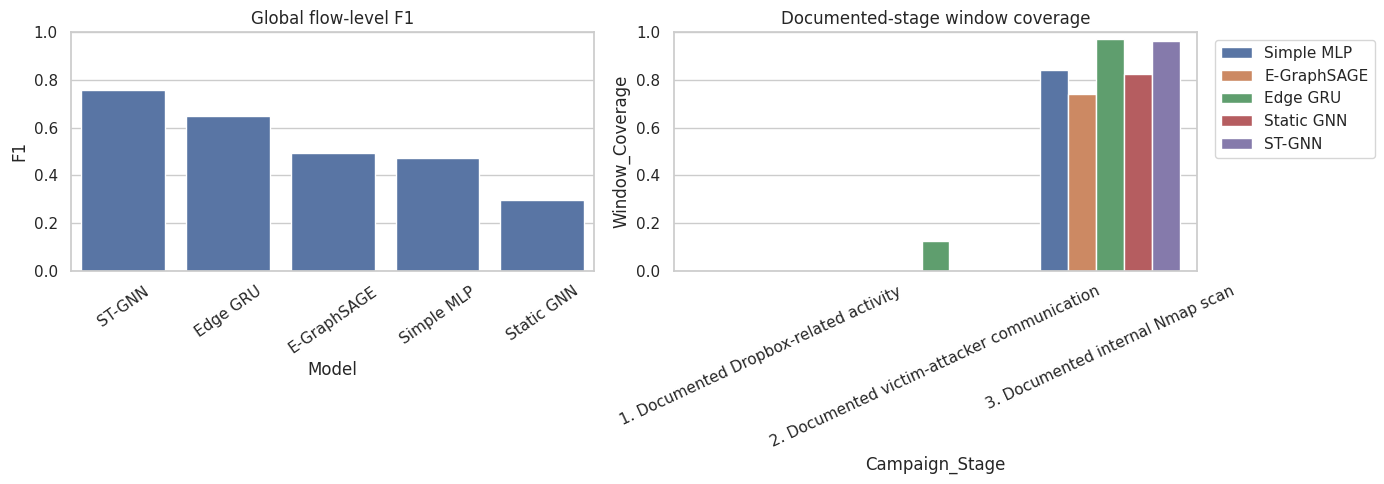

In [ ]:
# Compact plots for the paper-development stage. Review before publication.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=global_metrics,
    x="Model",
    y="F1",
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set_ylim(0, 1)
axes[0].set_title("Global flow-level F1")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=stage_metrics,
    x="Campaign_Stage",
    y="Window_Coverage",
    hue="Model",
    ax=axes[1],
)
axes[1].set_ylim(0, 1)
axes[1].set_title("Documented-stage window coverage")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "corrected_global_and_stage_performance.png", dpi=300)
plt.show()


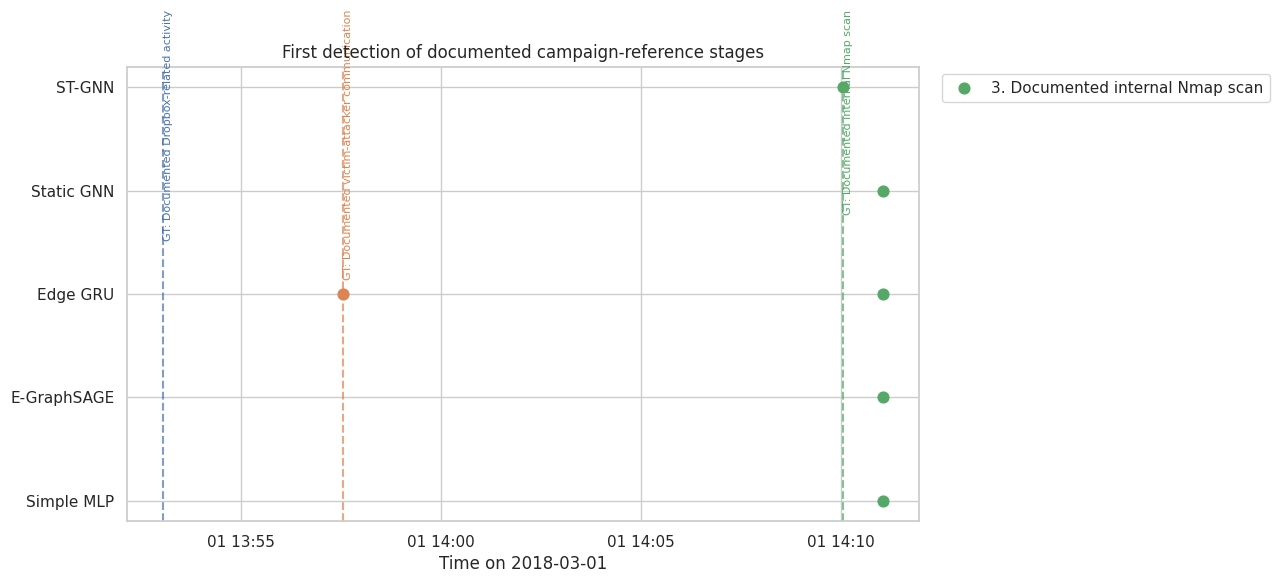

In [ ]:
# Timeline: corrected campaign-stage onset and first detected reference event.

timeline = stage_latency.copy()
timeline["First_GT"] = pd.to_datetime(timeline["First_GT"])
timeline["First_TP"] = pd.to_datetime(timeline["First_TP"])

fig, ax = plt.subplots(figsize=(13, 6))
model_order = list(MODEL_SPECS)

for stage_idx, stage in enumerate(DOCUMENTED_STAGES):
    stage_part = timeline[timeline["Campaign_Stage"].eq(stage)]
    first_gt = stage_part["First_GT"].dropna().min()
    if pd.notna(first_gt):
        ax.axvline(first_gt, color=f"C{stage_idx}", linestyle="--", alpha=0.7)
        ax.text(
            first_gt,
            len(model_order) - 0.25,
            f"GT: {stage.split('. ', 1)[1]}",
            rotation=90,
            va="top",
            fontsize=8,
            color=f"C{stage_idx}",
        )

    for model_idx, model_name in enumerate(model_order):
        row = stage_part[stage_part["Model"].eq(model_name)]
        if not row.empty and pd.notna(row["First_TP"].iloc[0]):
            ax.scatter(
                row["First_TP"].iloc[0],
                model_idx,
                color=f"C{stage_idx}",
                s=60,
                label=stage if model_idx == 0 else None,
            )

ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order)
ax.set_title("First detection of documented campaign-reference stages")
ax.set_xlabel("Time on 2018-03-01")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "corrected_campaign_stage_timeline.png", dpi=300)
plt.show()


In [ ]:
# Save all compact result tables used for interpretation.
global_metrics.to_csv(OUTPUT_DIR / "summary_global_metrics.csv", index=False)
endpoint_activity.to_csv(OUTPUT_DIR / "summary_endpoint_activity.csv", index=False)
fp_concentration.to_csv(OUTPUT_DIR / "summary_fp_concentration.csv", index=False)
fp_source_all.to_csv(OUTPUT_DIR / "summary_fp_sources_all_models.csv", index=False)
stage_ground_truth.to_csv(OUTPUT_DIR / "summary_stage_ground_truth.csv", index=False)
stage_metrics.to_csv(OUTPUT_DIR / "summary_stage_detection.csv", index=False)
stage_latency.to_csv(OUTPUT_DIR / "summary_stage_latency.csv", index=False)
chain_lead_time.to_csv(OUTPUT_DIR / "summary_chain_lead_time.csv", index=False)
lead_event_details.to_csv(OUTPUT_DIR / "summary_lead_event_details.csv", index=False)
stgnn_edgegru_overlap.to_csv(
    OUTPUT_DIR / "summary_stgnn_edgegru_overlap.csv",
    index=False,
)

print("Saved corrected summaries to:", OUTPUT_DIR)


Saved corrected summaries to: /content/drive/MyDrive/nids-mitre/analysis_mitre_corrected_v1


## 9. Interpretation checklist and next steps

Use the executed outputs to decide what can be stated in the paper:

1. **Decoder correction.** State that a post-hoc global-node-ID decoder was inconsistent with graph construction. A raw-to-graph audit recovered a conflict-free bijection and verified edge counts/order and labels. Since IDs inside the graphs were consistent, no retraining was required; IP-attributed analyses were recomputed.
2. **No lateral-movement claim from this scenario.** Refer to the documented internal activity as Nmap scanning, internal reconnaissance, or ATT&CK Discovery. Ports such as SMB/RDP/SSH express targets of a scan, not successful authentication, remote execution, or host compromise.
3. **Lead time.** Report a lead time only from `Detected_Precursor_Lead_Minutes`, accompanied by `Chain_Covered=True`. Identify which documented precursor caused it. Keep `GT_Opportunity_Minutes` as scenario timing. Treat source/either-endpoint alert lead as secondary operational analysis and disclose both its native-label status and corrected `Campaign_GT` status.
4. **ST-GNN and Edge GRU.** Do not select a winner from one attractive number. Compare global precision/recall/F1, stage flow recall, window coverage, timing, and matched detection overlap. Present Edge GRU as a strong temporal baseline or co-leading model if the executed results support that description.
5. **Topology.** An ST-GNN advantage over Edge GRU is evidence consistent with useful topology, not proof. A defensible topology claim requires the matched, retrained spatial-ablation experiment across seeds. Report uncertainty across seeds/windows rather than only champion checkpoints.
6. **Dataset limitation.** The corrected dataset documentation reports substantial infiltration-label corruption. Describe campaign-stage attribution as endpoint/time-based scenario analysis and ATT&CK fields as supported or candidate hypotheses, not native tactic ground truth.
7. **Thresholds.** Keep the validation-derived champion thresholds. Do not tune thresholds or whitelist hosts using Day-2 test false positives.

Possible paper framing after running the notebook:

> Rather than claiming hours of advance warning for lateral movement, we evaluate whether models identify documented precursor communications before the onset of a later internal reconnaissance phase. We distinguish the temporal opportunity present in the ground truth from model-detected malicious precursors and broader host alerts. This yields a more conservative, reproducible assessment of multi-stage campaign coverage.
